## Objective (Phase 5.1 — Baseline Modeling, No ML)

Goal: construct SOC-style "normal baselines" from CICIDS telemetry.

This notebook builds robust BENIGN baselines using:
- median + IQR (robust stats)
- percentile thresholds (p90/p95/p99)
- drift visibility across multiple source files (multi-day realism)
- entity approximations (Src IP / Dst Port if available)

Key lesson from Phase 3.5:
BENIGN flows can exceed extreme thresholds → naive single-feature detections cause false positives.


In [5]:
import os

# Force all outputs into the Phase 5 folder (absolute path)
PHASE5_DIR = r"D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5"

OUTPUT_DIR = os.path.join(PHASE5_DIR, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("✅ Phase 5 outputs will be saved to:")
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)


✅ Phase 5 outputs will be saved to:
FIG_DIR: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\figures
TAB_DIR: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables


In [6]:
DATA_DIR = r"D:\MachineLearningCVE"

FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

paths = [os.path.join(DATA_DIR, f) for f in FILES]

dfs = []
for p in paths:
    df_part = pd.read_csv(p, low_memory=False)
    df_part.columns = [c.strip() for c in df_part.columns]
    df_part["source_file"] = os.path.basename(p)  # SOC useful
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)
df.head()


Combined shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv


In [7]:
# Normalize columns again (safe)
df.columns = [c.strip() for c in df.columns]

# Replace infinities with NaN for numeric columns so stats don't break
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# Find label column
label_candidates = ["Label", "label", "Class", "class", "Attack", "attack"]
label_col = next((c for c in label_candidates if c in df.columns), None)

label_col


'Label'

In [8]:
assert label_col is not None, "Label column not found. Check dataset schema."
df[label_col] = df[label_col].astype(str).str.strip()

df[label_col].value_counts().head(20)


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [9]:
benign_values = ["BENIGN", "Benign", "benign", "Normal", "NORMAL"]

df_benign = df[df[label_col].isin(benign_values)].copy()

print("BENIGN subset shape:", df_benign.shape)
df_benign[label_col].value_counts()


BENIGN subset shape: (2273097, 80)


Label
BENIGN    2273097
Name: count, dtype: int64

In [10]:
baseline_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
]

missing = [f for f in baseline_features if f not in df_benign.columns]
missing

[]

In [11]:
def robust_baseline_summary(data: pd.DataFrame, features):
    rows = []
    for f in features:
        x = pd.to_numeric(data[f], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        
        row = {
            "feature": f,
            "count": len(x),
            "median": x.median(),
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "p90": x.quantile(0.90),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
            "tukey_low": q1 - 1.5 * iqr,
            "tukey_high": q3 + 1.5 * iqr,
        }
        rows.append(row)
    return pd.DataFrame(rows)

baseline_table = robust_baseline_summary(df_benign, baseline_features)
baseline_table


,feature,count,median,q1,q3,iqr,p90,p95,p99,tukey_low,tukey_high
0,Flow Duration,2273097,30996.000000,174.000000,452186.00000,452012.000000,5.812328e+07,1.133270e+08,1.180055e+08,-677844.000000,1.130204e+06
1,Total Fwd Packets,2273097,2.000000,2.000000,4.00000,2.000000,1.400000e+01,2.100000e+01,5.500000e+01,-1.000000,7.000000e+00
2,Total Backward Packets,2273097,2.000000,1.000000,2.00000,1.000000,1.200000e+01,1.900000e+01,6.800000e+01,-0.500000,3.500000e+00
3,Flow Bytes/s,2271320,5149.772552,127.822011,260869.56520,260741.743189,1.561497e+06,3.000000e+06,1.625000e+07,-390984.792772,6.519822e+05
4,Flow Packets/s,2271320,122.526496,14.545597,21390.37433,21375.828733,5.714286e+04,5.652174e+05,1.000000e+06,-32049.197502,5.345412e+04


In [12]:
out_path = os.path.join(TAB_DIR, "5.1_benign_baseline_table.csv")
baseline_table.to_csv(out_path, index=False)
print("Saved:", out_path)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.1_benign_baseline_table.csv


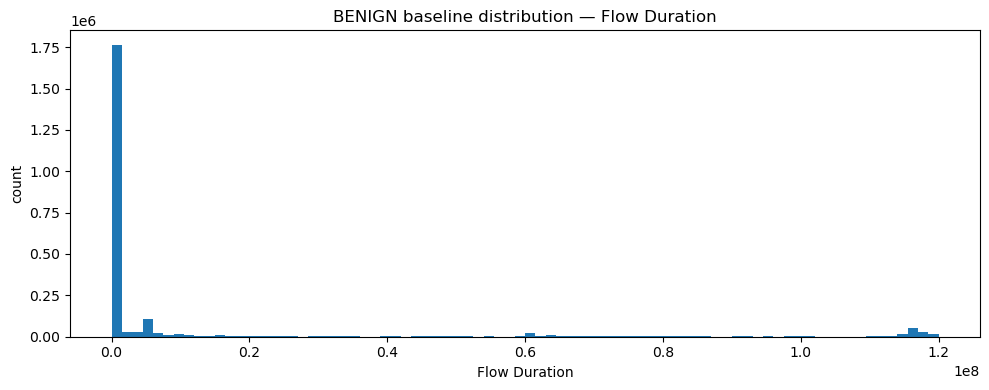

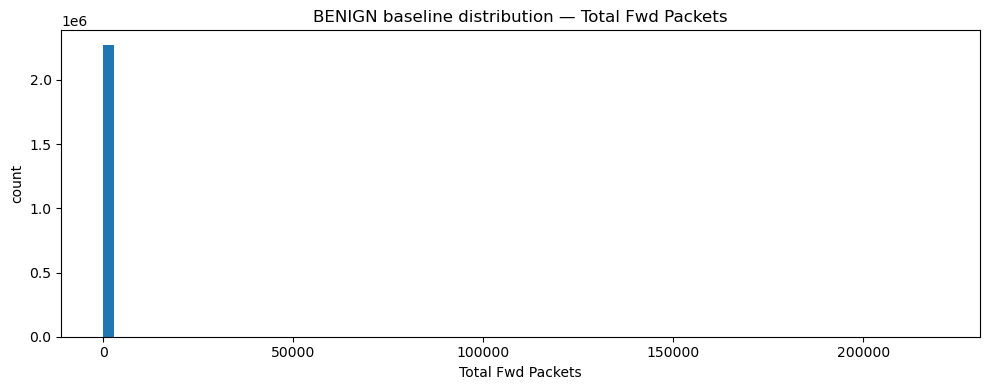

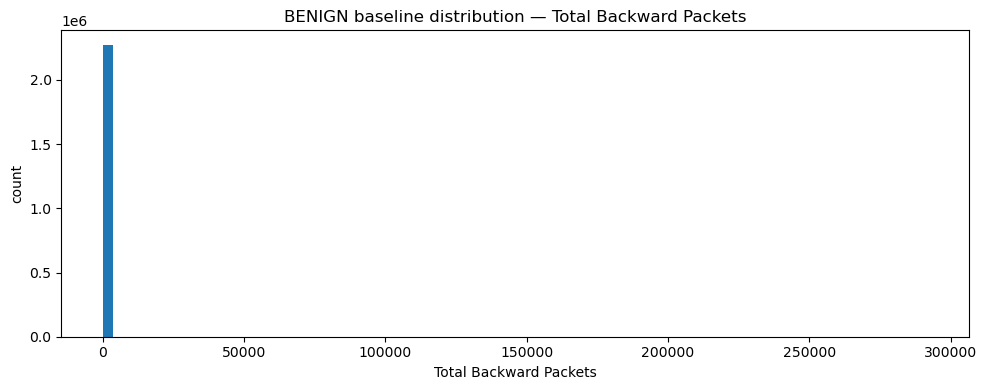

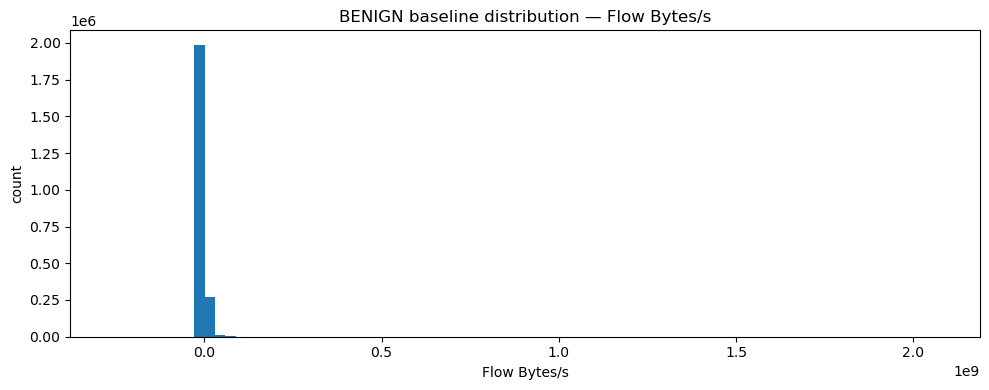

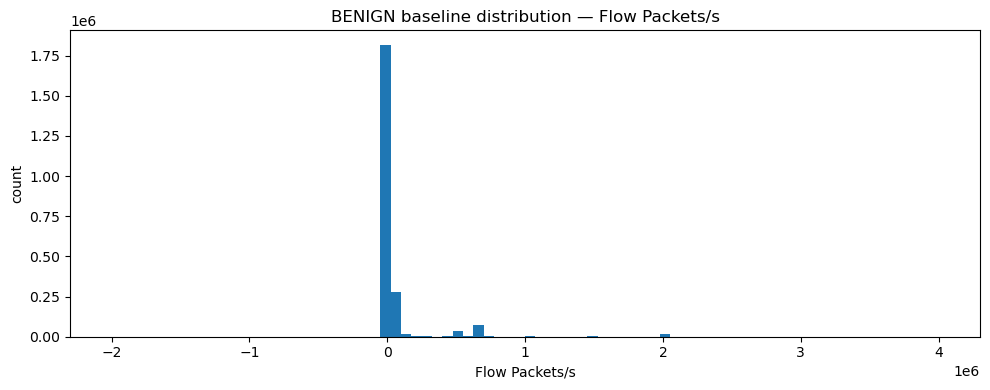

Saved histograms to: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\figures


In [13]:
def plot_hist(data, feature, bins=80):
    x = pd.to_numeric(data[feature], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure(figsize=(10, 4))
    plt.hist(x, bins=bins)
    plt.title(f"BENIGN baseline distribution — {feature}")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.tight_layout()

for f in baseline_features:
    plot_hist(df_benign, f)
    fig_path = os.path.join(FIG_DIR, f"5.1_hist_{f.replace('/','_').replace(' ','_')}.png")
    plt.savefig(fig_path, dpi=220)
    plt.show()

print("Saved histograms to:", FIG_DIR)


In [14]:
def per_file_quantiles(data, feature, group_col="source_file"):
    rows = []
    for src, g in data.groupby(group_col):
        x = pd.to_numeric(g[feature], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if len(x) == 0:
            continue
        rows.append({
            "source_file": src,
            "feature": feature,
            "count": len(x),
            "median": x.median(),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
        })
    return pd.DataFrame(rows)

drift_tables = []
for f in baseline_features:
    drift_tables.append(per_file_quantiles(df_benign, f))

drift_df = pd.concat(drift_tables, ignore_index=True)
drift_df.head(20)


,source_file,feature,count,median,p95,p99
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,Flow Duration,97718,171388.5,9.806904e+07,1.175929e+08
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,Flow Duration,127537,30964.0,1.155276e+08,1.181588e+08
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,Flow Duration,189067,31085.0,1.152629e+08,1.182093e+08
3,Monday-WorkingHours.pcap_ISCX.csv,Flow Duration,529918,31303.0,1.022153e+08,1.177445e+08
4,Thursday-WorkingHours-Afternoon-Infilteration....,Flow Duration,288566,306.0,9.949129e+07,1.178167e+08
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,Flow Duration,168186,31213.0,1.156376e+08,1.181610e+08
6,Tuesday-WorkingHours.pcap_ISCX.csv,Flow Duration,432074,31286.0,1.149205e+08,1.180942e+08
7,Wednesday-workingHours.pcap_ISCX.csv,Flow Duration,440031,31047.0,1.153003e+08,1.181122e+08
8,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,Total Fwd Packets,97718,2.0,1.700000e+01,4.700000e+01
9,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,Total Fwd Packets,127537,2.0,2.200000e+01,6.100000e+01


In [15]:
drift_out = os.path.join(TAB_DIR, "5.1_filewise_baseline_drift.csv")
drift_df.to_csv(drift_out, index=False)
print("Saved:", drift_out)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.1_filewise_baseline_drift.csv


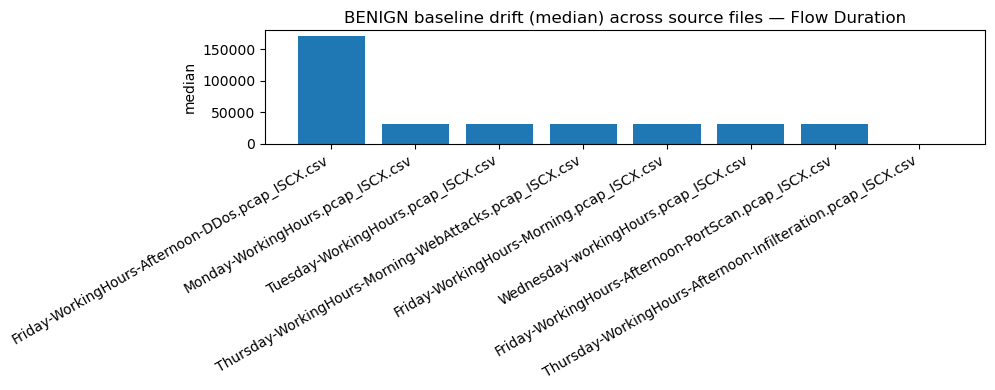

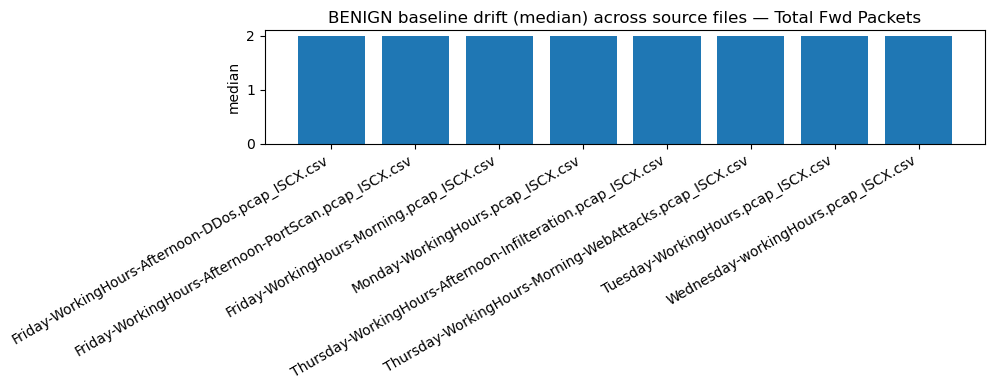

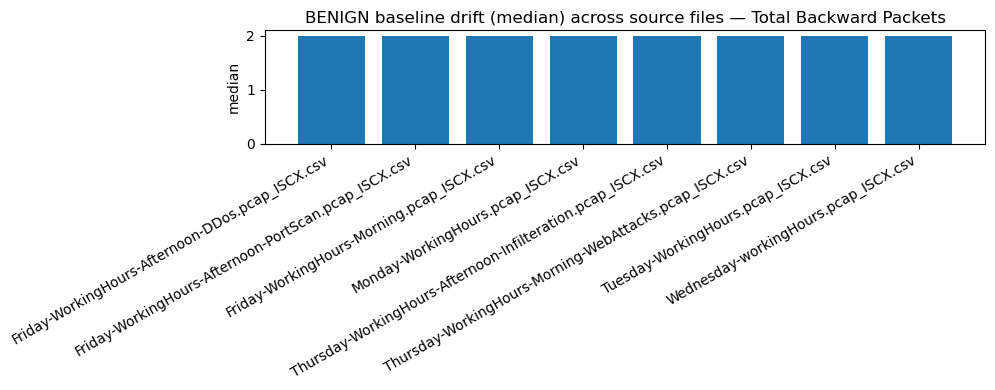

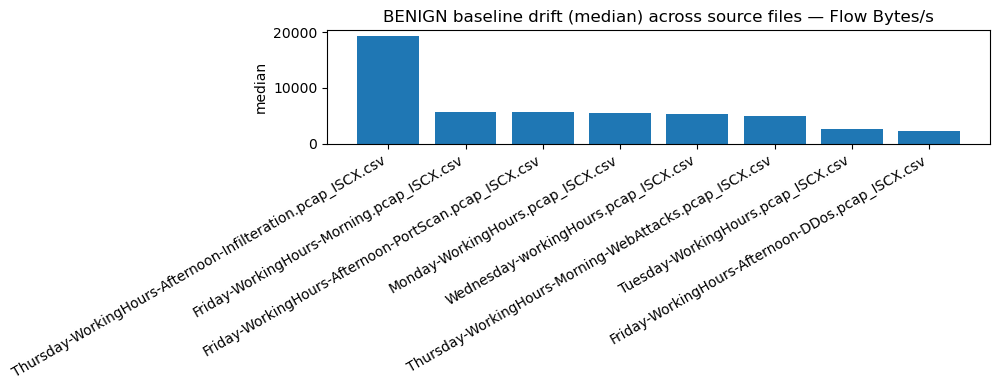

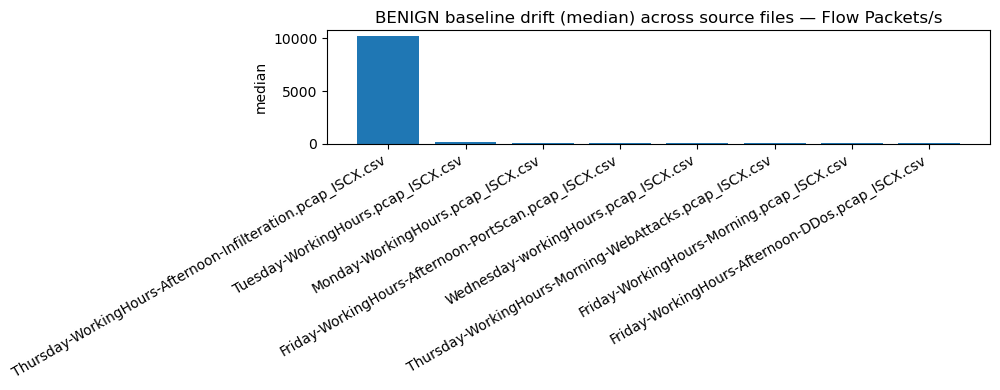

Saved drift plots to: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\figures


In [16]:
for f in baseline_features:
    sub = drift_df[drift_df["feature"] == f].sort_values("median", ascending=False)
    
    plt.figure(figsize=(10, 4))
    plt.bar(sub["source_file"], sub["median"])
    plt.xticks(rotation=30, ha="right")
    plt.title(f"BENIGN baseline drift (median) across source files — {f}")
    plt.ylabel("median")
    plt.tight_layout()
    
    fig_path = os.path.join(FIG_DIR, f"5.1_drift_median_{f.replace('/','_').replace(' ','_')}.png")
    plt.savefig(fig_path, dpi=220)
    plt.show()

print("Saved drift plots to:", FIG_DIR)


In [17]:
if "Src IP" in df_benign.columns:
    top_entities = df_benign["Src IP"].value_counts().head(10).index.tolist()
    df_top = df_benign[df_benign["Src IP"].isin(top_entities)].copy()

    entity_baseline = df_top.groupby("Src IP")[baseline_features].median(numeric_only=True).reset_index()

    entity_out = os.path.join(TAB_DIR, "5.1_entity_baseline_srcip_median_top10.csv")
    entity_baseline.to_csv(entity_out, index=False)
    print("Saved:", entity_out)

    entity_baseline.head()
else:
    print("Src IP column not found — skipping entity baseline.")


Src IP column not found — skipping entity baseline.


In [18]:
# Split BENIGN baseline into 3 slices and compare medians (stability proxy)
n = len(df_benign)
s1 = df_benign.iloc[: n//3]
s2 = df_benign.iloc[n//3 : 2*n//3]
s3 = df_benign.iloc[2*n//3 :]

def slice_medians(slice_df, features, name):
    med = slice_df[features].median(numeric_only=True)
    return pd.DataFrame({"feature": features, name: med.values})

m1 = slice_medians(s1, baseline_features, "slice_1_median")
m2 = slice_medians(s2, baseline_features, "slice_2_median")
m3 = slice_medians(s3, baseline_features, "slice_3_median")

stability = m1.merge(m2, on="feature").merge(m3, on="feature")
stability


,feature,slice_1_median,slice_2_median,slice_3_median
0,Flow Duration,47520.000000,28989.000000,30429.000000
1,Total Fwd Packets,2.000000,2.000000,2.000000
2,Total Backward Packets,2.000000,2.000000,2.000000
3,Flow Bytes/s,4051.101293,5145.309944,6630.886142
4,Flow Packets/s,84.139672,129.756382,128.737408


In [19]:
stab_out = os.path.join(TAB_DIR, "5.1_baseline_stability_slices.csv")
stability.to_csv(stab_out, index=False)
print("Saved:", stab_out)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.1_baseline_stability_slices.csv


## Takeaways (Phase 5.1)

- BENIGN traffic contains heavy tails → baselines must be robust (median/IQR + quantiles).
- Rate-based features (`Bytes/s`, `Packets/s`) are informative but risky due to benign spikes.
- Multi-file drift confirms SOC reality: "normal" changes across days and activity conditions.
- Entity/service baselines (Src IP / Dst Port) approximate real SOC baselining approaches.
- Baselines enable Phase 5.2 (minimal detector) and Phase 5.3 (alert gating).
